# Thử nghiệm với các model Machine Learning truyền thống

**Người thực hiện:** Mai


## Mục tiêu

- Huấn luyện nhiều mô hình để dự đoán `depression_label`.
- So sánh các metric: Accuracy, Precision, Recall, F1, Macro F1, ROC-AUC.
- Đánh giá bằng cross-validation, validation set gốc và test set cuối cùng.

Mô hình thử nghiệm:
- Decision Tree
- Random Forest
- XGBoost nếu môi trường đã cài
- LightGBM nếu môi trường đã cài


In [1]:
import os
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    make_scorer,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

try:
    from lightgbm import LGBMClassifier
    HAS_LIGHTGBM = True
except Exception:
    HAS_LIGHTGBM = False

print(f'XGBoost available: {HAS_XGBOOST}')
print(f'LightGBM available: {HAS_LIGHTGBM}')


XGBoost available: True
LightGBM available: False


In [2]:
TRAIN_PATH = '../data/processed/train_data.csv'
VAL_PATH = '../data/processed/validation_data.csv'
TEST_PATH = '../data/processed/test_data.csv'

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f'Không tìm thấy file: {p}')

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

# Data quality: đồng bộ schema, xử lý missing/inf, ép target về int
TARGET = 'depression_label'
common_cols = [c for c in train_df.columns if c in val_df.columns and c in test_df.columns]
train_df = train_df[common_cols].copy()
val_df = val_df[common_cols].copy()
test_df = test_df[common_cols].copy()

for df_ in [train_df, val_df, test_df]:
    df_.replace([np.inf, -np.inf], np.nan, inplace=True)
    num_cols = df_.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        if df_[col].isnull().any():
            df_[col] = df_[col].fillna(df_[col].median())
    if TARGET in df_.columns:
        df_[TARGET] = df_[TARGET].astype(int)

print('Loaded datasets:')
print(f'  train: {train_df.shape}')
print(f'  val:   {val_df.shape}')
print(f'  test:  {test_df.shape}')
print('\nTrain label distribution:')
print(train_df[TARGET].value_counts().sort_index())

Loaded datasets:
  train: (2590, 19)
  val:   (555, 19)
  test:  (555, 19)

Train label distribution:
depression_label
0    2159
1     431
Name: count, dtype: int64


In [3]:
TARGET = 'depression_label'

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_val = val_df.drop(columns=[TARGET])
y_val = val_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

# Đảm bảo thứ tự cột đồng nhất giữa train/val/test
X_val = X_val.reindex(columns=X_train.columns)
X_test = X_test.reindex(columns=X_train.columns)

print(f'Features: {X_train.shape[1]}')
print(f'Positive rate (train): {y_train.mean():.4f}')
print(f'Positive rate (val):   {y_val.mean():.4f}')
print(f'Positive rate (test):  {y_test.mean():.4f}')

Features: 18
Positive rate (train): 0.1664
Positive rate (val):   0.1658
Positive rate (test):  0.1658


## 3. Huấn luyện các mô hình ML cơ bản

Các model được khai báo trước, chưa xử lý mất cân bằng ở bước này:
- Decision Tree
- Random Forest
- XGBoost nếu môi trường có `xgboost`
- LightGBM nếu môi trường có `lightgbm`


In [4]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = (neg / pos) if pos > 0 else 1.0
minority_label = y_train.value_counts().idxmin()

base_estimators = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
}

class_weight_estimators = {
    'DecisionTree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced_subsample',
        n_jobs=-1,
    ),
}

if HAS_XGBOOST:
    base_estimators['XGBoost'] = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
    )
    class_weight_estimators['XGBoost'] = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1,
    )
print('Models:', list(base_estimators.keys()))
print(f'Minority label: {minority_label}')


Models: ['DecisionTree', 'RandomForest', 'XGBoost']
Minority label: 1


## 4. Xử lý mất cân bằng

Với mỗi mô hình, notebook tạo 3 cấu hình:
- `Baseline`: không xử lý mất cân bằng
- `Class Weight`: dùng `class_weight='balanced'` hoặc `scale_pos_weight` cho XGBoost
- `SMOTE`: đặt `SMOTE()` trong `Pipeline` để tránh data leakage


In [5]:
def build_candidate(model_name, imbalance_method):
    if imbalance_method == 'Baseline':
        return clone(base_estimators[model_name])
    if imbalance_method == 'Class Weight':
        return clone(class_weight_estimators[model_name])
    if imbalance_method == 'SMOTE':
        return ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('model', clone(base_estimators[model_name])),
        ])
    raise ValueError(f'Unknown imbalance method: {imbalance_method}')

imbalance_methods = ['Baseline', 'Class Weight', 'SMOTE']

candidate_rows = []
for model_name in base_estimators:
    for method in imbalance_methods:
        candidate_rows.append({
            'model': model_name,
            'imbalance_method': method,
            'candidate_key': f'{model_name}|{method}',
        })

candidate_table = pd.DataFrame(candidate_rows)
display(candidate_table)


,model,imbalance_method,candidate_key
0,DecisionTree,Baseline,DecisionTree|Baseline
1,DecisionTree,Class Weight,DecisionTree|Class Weight
2,DecisionTree,SMOTE,DecisionTree|SMOTE
3,RandomForest,Baseline,RandomForest|Baseline
4,RandomForest,Class Weight,RandomForest|Class Weight
5,RandomForest,SMOTE,RandomForest|SMOTE
6,XGBoost,Baseline,XGBoost|Baseline
7,XGBoost,Class Weight,XGBoost|Class Weight
8,XGBoost,SMOTE,XGBoost|SMOTE


## 5. Cross Validation

Sử dụng `StratifiedKFold(k=5)`.

Với SMOTE, `SMOTE()` nằm trong `Pipeline`, nên trong mỗi fold:
- Fit SMOTE chỉ trên `train_fold`
- Đánh giá trên `val_fold` gốc

Metric gồm:
- Accuracy
- Precision
- Recall
- F1-score
- Macro F1
- Minority Recall


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'macro_f1': 'f1_macro',
    'minority_recall': make_scorer(recall_score, pos_label=minority_label, zero_division=0),
}

cv_rows = []
for _, cfg in candidate_table.iterrows():
    estimator = build_candidate(cfg['model'], cfg['imbalance_method'])
    scores = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    row = cfg.to_dict()
    for metric in scoring:
        vals = scores[f'test_{metric}']
        row[f'cv_{metric}_mean'] = vals.mean()
        row[f'cv_{metric}_std'] = vals.std()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values(
    by=['cv_f1_mean', 'cv_minority_recall_mean'],
    ascending=False,
)

display(cv_results.round(4))


,model,imbalance_method,candidate_key,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_macro_f1_mean,cv_macro_f1_std,cv_minority_recall_mean,cv_minority_recall_std
5,RandomForest,SMOTE,RandomForest|SMOTE,0.9135,0.0100,0.6931,0.0311,0.8655,0.0186,0.7694,0.0231,0.8581,0.0147,0.8655,0.0186
7,XGBoost,Class Weight,XGBoost|Class Weight,0.9120,0.0071,0.6931,0.0261,0.8492,0.0165,0.7628,0.0141,0.8544,0.0093,0.8492,0.0165
8,XGBoost,SMOTE,XGBoost|SMOTE,0.9069,0.0082,0.6904,0.0224,0.8005,0.0478,0.7407,0.0267,0.8420,0.0156,0.8005,0.0478
3,RandomForest,Baseline,RandomForest|Baseline,0.9081,0.0130,0.7008,0.0349,0.7820,0.0428,0.7390,0.0370,0.8416,0.0224,0.7820,0.0428
6,XGBoost,Baseline,XGBoost|Baseline,0.9042,0.0093,0.7006,0.0292,0.7425,0.0246,0.7208,0.0259,0.8315,0.0158,0.7425,0.0246
4,RandomForest,Class Weight,RandomForest|Class Weight,0.9023,0.0127,0.6913,0.0314,0.7449,0.0521,0.7168,0.0398,0.8289,0.0236,0.7449,0.0521
0,DecisionTree,Baseline,DecisionTree|Baseline,0.8950,0.0080,0.6877,0.0258,0.6776,0.0363,0.6820,0.0249,0.8096,0.0147,0.6776,0.0363
2,DecisionTree,SMOTE,DecisionTree|SMOTE,0.8892,0.0119,0.6662,0.0376,0.6730,0.0500,0.6686,0.0368,0.8010,0.0218,0.6730,0.0500
1,DecisionTree,Class Weight,DecisionTree|Class Weight,0.8861,0.0091,0.6748,0.0329,0.6125,0.0448,0.6410,0.0320,0.7866,0.0183,0.6125,0.0448


## 6. Hyperparameter Tuning

Dùng `GridSearchCV` kết hợp với `StratifiedKFold`.

Với SMOTE, grid search chạy trên `Pipeline(SMOTE(), Model())`, nên SMOTE chỉ fit trên train fold.

Metric tối ưu là F1 của lớp depression (`depression_label=1`). Macro F1 vẫn được giữ để báo cáo phụ.


In [7]:
param_grids = {
    'DecisionTree': {
        'max_depth': [5, 7, 9, None],
        'min_samples_leaf': [8, 15, 25],
        'min_samples_split': [20, 40, 80],
    },
    'RandomForest': {
        'n_estimators': [300, 500],
        'max_depth': [8, 10, None],
        'min_samples_leaf': [4, 6, 10],
        'max_features': ['sqrt', 'log2'],
    },
}

if HAS_XGBOOST:
    param_grids['XGBoost'] = {
        'n_estimators': [400, 700],
        'learning_rate': [0.03, 0.05],
        'max_depth': [3, 4],
        'min_child_weight': [4, 6],
        'gamma': [0.1, 0.25],
    }

if HAS_LIGHTGBM:
    param_grids['LightGBM'] = {
        'n_estimators': [300, 500],
        'learning_rate': [0.03, 0.05],
        'max_depth': [-1, 6, 10],
        'num_leaves': [15, 31],
        'min_child_samples': [10, 20],
    }


def grid_for_candidate(model_name, imbalance_method):
    grid = param_grids.get(model_name, {})
    if imbalance_method == 'SMOTE':
        return {f'model__{k}': v for k, v in grid.items()}
    return grid


In [8]:
tuning_rows = []
tuned_estimators = {}

for _, cfg in candidate_table.iterrows():
    model_name = cfg['model']
    method = cfg['imbalance_method']
    candidate_key = cfg['candidate_key']

    search = GridSearchCV(
        estimator=build_candidate(model_name, method),
        param_grid=grid_for_candidate(model_name, method),
        scoring=make_scorer(f1_score, pos_label=1, zero_division=0),
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)

    tuned_estimators[candidate_key] = search.best_estimator_
    tuning_rows.append({
        'model': model_name,
        'imbalance_method': method,
        'candidate_key': candidate_key,
        'best_cv_f1': search.best_score_,
        'best_params': search.best_params_,
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values(by='best_cv_f1', ascending=False)
display(tuning_results)


,model,imbalance_method,candidate_key,best_cv_f1,best_params
7,XGBoost,Class Weight,XGBoost|Class Weight,0.796696,"{'gamma': 0.25, 'learning_rate': 0.03, 'max_de..."
4,RandomForest,Class Weight,RandomForest|Class Weight,0.791438,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
5,RandomForest,SMOTE,RandomForest|SMOTE,0.787279,"{'model__max_depth': 10, 'model__max_features'..."
8,XGBoost,SMOTE,XGBoost|SMOTE,0.780531,"{'model__gamma': 0.1, 'model__learning_rate': ..."
1,DecisionTree,Class Weight,DecisionTree|Class Weight,0.775685,"{'max_depth': 5, 'min_samples_leaf': 15, 'min_..."
2,DecisionTree,SMOTE,DecisionTree|SMOTE,0.771284,"{'model__max_depth': 7, 'model__min_samples_le..."
0,DecisionTree,Baseline,DecisionTree|Baseline,0.762804,"{'max_depth': 5, 'min_samples_leaf': 15, 'min_..."
6,XGBoost,Baseline,XGBoost|Baseline,0.759055,"{'gamma': 0.1, 'learning_rate': 0.03, 'max_dep..."
3,RandomForest,Baseline,RandomForest|Baseline,0.749592,"{'max_depth': 8, 'max_features': 'sqrt', 'min_..."


In [16]:
def _predict_with_threshold(estimator, X, threshold=0.5):
    if hasattr(estimator, 'predict_proba'):
        prob = estimator.predict_proba(X)[:, 1]
        pred = (prob >= threshold).astype(int)
        return pred, prob
    pred = estimator.predict(X)
    return pred, None


def _final_model_from_estimator(estimator):
    if hasattr(estimator, 'named_steps') and 'model' in estimator.named_steps:
        return estimator.named_steps['model']
    return estimator


## 6.1. Đánh giá tuned models trên validation gốc

Sau khi `GridSearchCV` tìm best hyperparameters trên train folds, mỗi candidate được refit trên toàn bộ train set và đánh giá trên `validation_data.csv` gốc.

Chọn model ở bước sau dựa trên `val_f1`, không chọn trực tiếp bằng CV score.


In [17]:
validation_rows = []
fitted_models = {}

for _, row in tuning_results.iterrows():
    candidate_key = row['candidate_key']
    estimator = clone(tuned_estimators[candidate_key])
    estimator.fit(X_train, y_train)
    fitted_models[candidate_key] = estimator

    val_pred, val_prob = _predict_with_threshold(estimator, X_val, threshold=0.5)
    val_metrics = {
        'val_accuracy': accuracy_score(y_val, val_pred),
        'val_precision': precision_score(y_val, val_pred, zero_division=0),
        'val_recall': recall_score(y_val, val_pred, zero_division=0),
        'val_f1': f1_score(y_val, val_pred, zero_division=0),
        'val_macro_f1': f1_score(y_val, val_pred, average='macro', zero_division=0),
        'val_minority_recall': recall_score(y_val, val_pred, pos_label=minority_label, zero_division=0),
    }
    if val_prob is not None:
        val_metrics['val_roc_auc'] = roc_auc_score(y_val, val_prob)

    validation_rows.append({
        'model': row['model'],
        'imbalance_method': row['imbalance_method'],
        'candidate_key': candidate_key,
        'best_cv_f1': row['best_cv_f1'],
        'best_params': row['best_params'],
        **val_metrics,
    })

validation_results = pd.DataFrame(validation_rows).sort_values(by='val_f1', ascending=False)
display(validation_results.round(4))


,model,imbalance_method,candidate_key,best_cv_f1,best_params,val_accuracy,val_precision,val_recall,val_f1,val_macro_f1,val_minority_recall,val_roc_auc
3,XGBoost,SMOTE,XGBoost|SMOTE,0.7805,"{'model__gamma': 0.1, 'model__learning_rate': ...",0.9279,0.7000,0.9891,0.8198,0.8874,0.9891,0.9548
7,XGBoost,Baseline,XGBoost|Baseline,0.7591,"{'gamma': 0.1, 'learning_rate': 0.03, 'max_dep...",0.9297,0.7154,0.9565,0.8186,0.8875,0.9565,0.9564
1,RandomForest,Class Weight,RandomForest|Class Weight,0.7914,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.9261,0.6977,0.9783,0.8145,0.8842,0.9783,0.9594
5,DecisionTree,SMOTE,DecisionTree|SMOTE,0.7713,"{'model__max_depth': 7, 'model__min_samples_le...",0.9243,0.6984,0.9565,0.8073,0.8801,0.9565,0.9450
2,RandomForest,SMOTE,RandomForest|SMOTE,0.7873,"{'model__max_depth': 10, 'model__max_features'...",0.9243,0.6984,0.9565,0.8073,0.8801,0.9565,0.9594
0,XGBoost,Class Weight,XGBoost|Class Weight,0.7967,"{'gamma': 0.25, 'learning_rate': 0.03, 'max_de...",0.9207,0.6791,0.9891,0.8053,0.8778,0.9891,0.9521
8,RandomForest,Baseline,RandomForest|Baseline,0.7496,"{'max_depth': 8, 'max_features': 'sqrt', 'min_...",0.9261,0.7217,0.9022,0.8019,0.8783,0.9022,0.9596
6,DecisionTree,Baseline,DecisionTree|Baseline,0.7628,"{'max_depth': 5, 'min_samples_leaf': 15, 'min_...",0.9189,0.6880,0.9348,0.7926,0.8711,0.9348,0.9582
4,DecisionTree,Class Weight,DecisionTree|Class Weight,0.7757,"{'max_depth': 5, 'min_samples_leaf': 15, 'min_...",0.9099,0.6522,0.9783,0.7826,0.8629,0.9783,0.9437


## 7. So sánh kết quả

Bảng so sánh theo `Macro F1` và `Recall lớp thiểu số` cho từng model và từng phương pháp xử lý mất cân bằng.


In [18]:
comparison_macro_f1 = cv_results.pivot_table(
    index='model',
    columns='imbalance_method',
    values='cv_macro_f1_mean',
).reindex(columns=imbalance_methods)

comparison_minority_recall = cv_results.pivot_table(
    index='model',
    columns='imbalance_method',
    values='cv_minority_recall_mean',
).reindex(columns=imbalance_methods)

print('Macro F1 (CV mean)')
display(comparison_macro_f1.round(4))

print('Minority Recall (CV mean)')
display(comparison_minority_recall.round(4))


Macro F1 (CV mean)


imbalance_method,Baseline,Class Weight,SMOTE
model,,,
DecisionTree,0.8096,0.7866,0.8010
RandomForest,0.8416,0.8289,0.8581
XGBoost,0.8315,0.8544,0.8420


Minority Recall (CV mean)


imbalance_method,Baseline,Class Weight,SMOTE
model,,,
DecisionTree,0.6776,0.6125,0.6730
RandomForest,0.7820,0.7449,0.8655
XGBoost,0.7425,0.8492,0.8005


In [21]:
comparison_macro_f1 = validation_results.pivot_table(
    index='model',
    columns='imbalance_method',
    values='val_f1',
).reindex(columns=imbalance_methods)

comparison_minority_recall = validation_results.pivot_table(
    index='model',
    columns='imbalance_method',
    values='val_minority_recall',
).reindex(columns=imbalance_methods)

print('F1 (Validation)')
display(comparison_macro_f1.round(4))

print('Minority Recall (Validation)')
display(comparison_minority_recall.round(4))


F1 (Validation)


imbalance_method,Baseline,Class Weight,SMOTE
model,,,
DecisionTree,0.7926,0.7826,0.8073
RandomForest,0.8019,0.8145,0.8073
XGBoost,0.8186,0.8053,0.8198


Minority Recall (Validation)


imbalance_method,Baseline,Class Weight,SMOTE
model,,,
DecisionTree,0.9348,0.9783,0.9565
RandomForest,0.9022,0.9783,0.9565
XGBoost,0.9565,0.9891,0.9891


## 8. Chọn mô hình tốt nhất

Chọn candidate tốt nhất theo `val_f1` trên validation set gốc. CV chỉ dùng để tìm hyperparameters tốt trong bước tuning.


In [22]:
best_row = validation_results.sort_values(
    by='val_f1',
    ascending=False,
).iloc[0]

best_candidate_key = best_row['candidate_key']
best_model_name = best_row['model']
best_imbalance_method = best_row['imbalance_method']
best_params = best_row['best_params']

print(f'Best candidate: {best_candidate_key}')
print(f'Validation F1: {best_row["val_f1"]:.4f}')
print(f'Best CV F1 for params: {best_row["best_cv_f1"]:.4f}')
print('Best params:')
print(best_params)


Best candidate: XGBoost|SMOTE
Validation F1: 0.8198
Best CV F1 for params: 0.7805
Best params:
{'model__gamma': 0.1, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__min_child_weight': 6, 'model__n_estimators': 400}


## 9. Retrain

Train lại mô hình tốt nhất trên toàn bộ train set bằng best hyperparameters.


In [23]:
best_estimator = clone(tuned_estimators[best_candidate_key])
best_estimator.fit(X_train, y_train)
fitted_models[best_candidate_key] = best_estimator

print(f'Retrained best model on full train set: {best_candidate_key}')


Retrained best model on full train set: XGBoost|SMOTE


## 10. Final Evaluation

Đánh giá mô hình tốt nhất trên test set và xuất:
- Classification Report
- Confusion Matrix
- ROC Curve nếu binary
- Feature Importance cho RF/XGB/LightGBM/Decision Tree nếu model hỗ trợ


,candidate_key,model,imbalance_method,test_accuracy,test_precision,test_recall,test_f1,test_macro_f1,test_minority_recall,test_roc_auc
0,XGBoost|SMOTE,XGBoost,SMOTE,0.9027,0.6583,0.8587,0.7453,0.8426,0.8587,0.948


,precision,recall,f1-score,support
0,0.9701,0.9114,0.9399,463.0000
1,0.6583,0.8587,0.7453,92.0000
accuracy,0.9027,0.9027,0.9027,0.9027
macro avg,0.8142,0.8851,0.8426,555.0000
weighted avg,0.9184,0.9027,0.9076,555.0000


,pred_0,pred_1
true_0,422,41
true_1,13,79


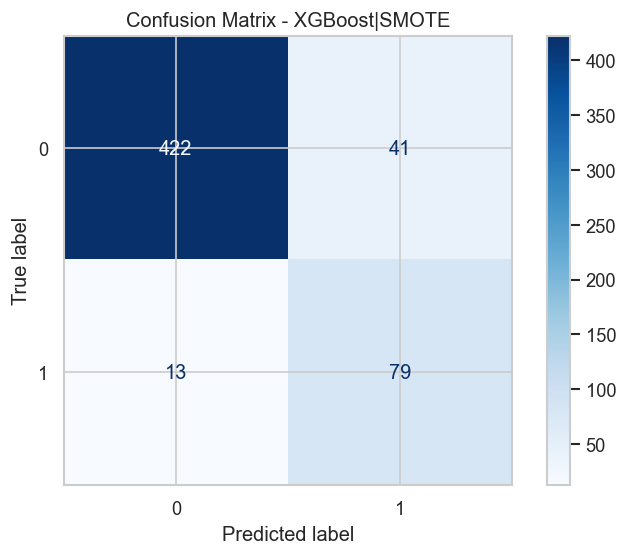

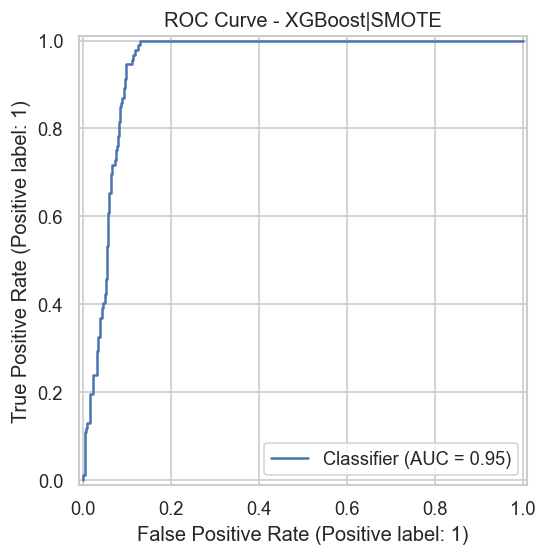

,feature,importance
8,stress_level,0.524102
14,sm_sleep_ratio,0.091256
9,anxiety_level,0.075557
5,academic_performance,0.065029
3,sleep_hours,0.053082
15,screen_sleep_ratio,0.027104
2,daily_social_media_hours,0.023590
7,social_interaction_level,0.019868
4,screen_time_before_sleep,0.019452
6,physical_activity,0.018887


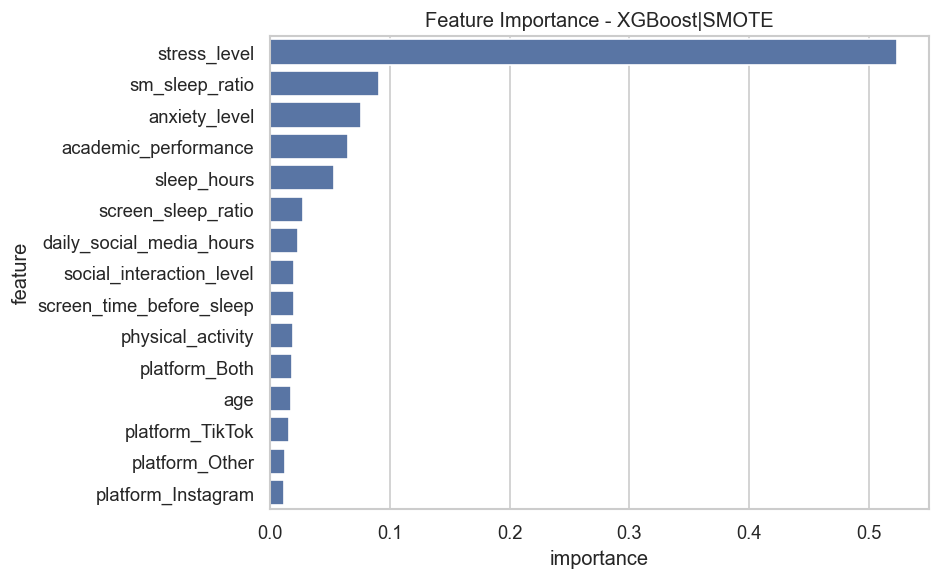

In [26]:
y_test_pred, y_test_prob = _predict_with_threshold(best_estimator, X_test, threshold=0.5)

final_metrics = {
    'candidate_key': best_candidate_key,
    'model': best_model_name,
    'imbalance_method': best_imbalance_method,
    'test_accuracy': accuracy_score(y_test, y_test_pred),
    'test_precision': precision_score(y_test, y_test_pred, zero_division=0),
    'test_recall': recall_score(y_test, y_test_pred, zero_division=0),
    'test_f1': f1_score(y_test, y_test_pred, zero_division=0),
    'test_macro_f1': f1_score(y_test, y_test_pred, average='macro', zero_division=0),
    'test_minority_recall': recall_score(y_test, y_test_pred, pos_label=minority_label, zero_division=0),
}
if y_test_prob is not None:
    final_metrics['test_roc_auc'] = roc_auc_score(y_test, y_test_prob)

final_metrics_df = pd.DataFrame([final_metrics])
display(final_metrics_df.round(4))

os.makedirs('../results/figures', exist_ok=True)

report_dict = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
classification_report_df = pd.DataFrame(report_dict).T
display(classification_report_df.round(4))

confusion_matrix_df = pd.DataFrame(
    confusion_matrix(y_test, y_test_pred),
    index=[f'true_{label}' for label in sorted(y_test.unique())],
    columns=[f'pred_{label}' for label in sorted(y_test.unique())],
)
display(confusion_matrix_df)

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap='Blues')
plt.title(f'Confusion Matrix - {best_candidate_key}')
plt.tight_layout()
plt.savefig('../results/figures/final_confusion_matrix.png', bbox_inches='tight')
plt.show()

if y_test_prob is not None:
    RocCurveDisplay.from_predictions(y_test, y_test_prob)
    plt.title(f'ROC Curve - {best_candidate_key}')
    plt.tight_layout()
    plt.savefig('../results/figures/final_roc_curve.png', bbox_inches='tight')
    plt.show()

final_model = _final_model_from_estimator(best_estimator)
if hasattr(final_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': final_model.feature_importances_,
    }).sort_values(by='importance', ascending=False)
    display(feature_importance.head(20))

    plt.figure(figsize=(8, 5))
    sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
    plt.title(f'Feature Importance - {best_candidate_key}')
    plt.tight_layout()
    plt.show()
else:
    feature_importance = pd.DataFrame(columns=['feature', 'importance'])
    print('Model không có feature_importances_.')


In [27]:
os.makedirs('../results/metrics', exist_ok=True)
os.makedirs('../models/ml', exist_ok=True)

cv_results.to_csv('../results/metrics/ml_metrics_cv.csv', index=False)
tuning_results.to_csv('../results/metrics/ml_tuning_results.csv', index=False)
validation_results.to_csv('../results/metrics/ml_validation_metrics.csv', index=False)
comparison_macro_f1.to_csv('../results/metrics/model_comparison_macro_f1.csv')
comparison_minority_recall.to_csv('../results/metrics/model_comparison_minority_recall.csv')
final_metrics_df.to_csv('../results/metrics/final_test_metrics.csv', index=False)
classification_report_df.to_csv('../results/metrics/final_classification_report.csv')
confusion_matrix_df.to_csv('../results/metrics/final_confusion_matrix.csv')
feature_importance.to_csv('../results/metrics/feature_importance_best_model.csv', index=False)

best_artifact = {
    'model': best_estimator,
    'candidate_key': best_candidate_key,
    'model_name': best_model_name,
    'imbalance_method': best_imbalance_method,
    'best_params': best_params,
    'feature_columns': list(X_train.columns),
    'minority_label': int(minority_label),
    'validation_metrics': best_row.to_dict(),
    'test_metrics': final_metrics,
}
joblib.dump(best_artifact, '../models/ml/best_model.pkl')

# Export top 3 tuned candidates theo validation F1, ?? refit tr?n train.
top3_rows = validation_results.head(3).copy()
export_rows = []
for rank, (_, row) in enumerate(top3_rows.iterrows(), start=1):
    candidate_key = row['candidate_key']
    estimator = fitted_models[candidate_key]
    test_pred, test_prob = _predict_with_threshold(estimator, X_test, threshold=0.5)
    test_metrics = {
        'test_accuracy': accuracy_score(y_test, test_pred),
        'test_precision': precision_score(y_test, test_pred, zero_division=0),
        'test_recall': recall_score(y_test, test_pred, zero_division=0),
        'test_f1': f1_score(y_test, test_pred, zero_division=0),
        'test_macro_f1': f1_score(y_test, test_pred, average='macro', zero_division=0),
        'test_minority_recall': recall_score(y_test, test_pred, pos_label=minority_label, zero_division=0),
    }
    if test_prob is not None:
        test_metrics['test_roc_auc'] = roc_auc_score(y_test, test_prob)

    safe_name = candidate_key.replace('|', '_').replace(' ', '_').lower()
    model_path = f'../models/ml/top{rank}_{safe_name}.pkl'
    artifact = {
        'model': estimator,
        'candidate_key': candidate_key,
        'model_name': row['model'],
        'imbalance_method': row['imbalance_method'],
        'best_params': row['best_params'],
        'feature_columns': list(X_train.columns),
        'minority_label': int(minority_label),
        'selection_metric': 'val_f1',
        'best_cv_f1': row['best_cv_f1'],
        'validation_metrics': row.to_dict(),
        'test_metrics': test_metrics,
    }
    joblib.dump(artifact, model_path)
    export_rows.append({
        'rank': rank,
        'candidate_key': candidate_key,
        'model': row['model'],
        'imbalance_method': row['imbalance_method'],
        'best_cv_f1': row['best_cv_f1'],
        'val_f1': row['val_f1'],
        'val_precision': row['val_precision'],
        'val_recall': row['val_recall'],
        **test_metrics,
        'path': model_path,
    })

exported_top_models = pd.DataFrame(export_rows)
exported_top_models.to_csv('../models/ml/exported_top_models.csv', index=False)

display(exported_top_models)
print('Saved best model: ../models/ml/best_model.pkl')

,rank,candidate_key,model,imbalance_method,best_cv_f1,val_f1,val_precision,val_recall,test_accuracy,test_precision,test_recall,test_f1,test_macro_f1,test_minority_recall,test_roc_auc,path
0,1,XGBoost|SMOTE,XGBoost,SMOTE,0.780531,0.819820,0.700000,0.989130,0.902703,0.658333,0.858696,0.745283,0.842575,0.858696,0.948023,../models/ml/top1_xgboost_smote.pkl
1,2,XGBoost|Baseline,XGBoost,Baseline,0.759055,0.818605,0.715447,0.956522,0.899099,0.657895,0.815217,0.728155,0.833104,0.815217,0.951075,../models/ml/top2_xgboost_baseline.pkl
2,3,RandomForest|Class Weight,RandomForest,Class Weight,0.791438,0.814480,0.697674,0.978261,0.911712,0.674797,0.902174,0.772093,0.858672,0.902174,0.947765,../models/ml/top3_randomforest_class_weight.pkl


Saved best model: ../models/ml/best_model.pkl
